# Model Architecture (PyTorch) - Build, Verify, Convert

**Notebook role:** Phase 4 (PyTorch port). Builds all three model variants in PyTorch, verifies forward pass shapes, runs INT8 TFLite conversion via `litert-torch` to measure real binary sizes, and produces an `eda_model.pdf` briefing for the report.

**Outputs**
- `other_files/figs_eda/model_*.png` -- architecture and sizing figures
- `other_files/eda_model.pdf` -- briefing PDF
- `other_files/tflite_models/*.tflite` -- one TFLite file per variant (untrained, for size verification only)

**What we check**
1. All three variants build without errors
2. Forward pass produces correct output shapes and value ranges
3. INT8 TFLite conversion via `litert-torch` fits under the 800 KB flash budget
4. Tensor arena estimate fits under the 400 KB SRAM budget
5. The op set contains only TFLM-supported operations (no `SUM`, no `LSTM/GRU/RNN`)


## 0. Setup

In [1]:
import sys, os, gc, tempfile
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["OMP_NUM_THREADS"] = "1"
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch
torch.set_num_threads(1)

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150

ROOT = Path("..").resolve()
OTHER_FILES = ROOT / "other_files"
sys.path.insert(0, str(OTHER_FILES))

from model_torch import (
    UWBLocalizer, build_model, MODEL_VARIANTS,
    T_CONTEXT, N_RADARS, N_ANT, N_BINS, N_IQ,
    GRID_H, GRID_W, COUNT_CLASSES,
)
from convert_to_litert import convert_float32, convert_int8, inspect_tflite

FIG_DIR     = OTHER_FILES / "figs_eda"
TFLITE_DIR  = OTHER_FILES / "tflite_models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TFLITE_DIR.mkdir(parents=True, exist_ok=True)

# Targets from the assignment
ESP32_FLASH_KB = 800
ESP32_SRAM_KB  = 400

print(f"PyTorch:    {torch.__version__}")
print(f"GPU avail:  {torch.cuda.is_available()}")
print(f"Variants:   {list(MODEL_VARIANTS)}")
print(f"Input:      ({T_CONTEXT}, {N_RADARS}, {N_ANT}, {N_BINS}, {N_IQ})")
print(f"Output:     heatmap (1, {GRID_H}, {GRID_W}) + count ({COUNT_CLASSES},)")
print(f"Budgets:    {ESP32_FLASH_KB} KB flash, {ESP32_SRAM_KB} KB SRAM")


PyTorch:    2.11.0+cpu
GPU avail:  False
Variants:   ['small', 'medium', 'large']
Input:      (8, 6, 3, 105, 2)
Output:     heatmap (1, 36, 24) + count (5,)
Budgets:    800 KB flash, 400 KB SRAM


## 1. Build all three variants

Build each variant and print a parameter count for the small one. The structure is identical for all three; only the channel widths differ.


In [2]:
variants = {}
for name in MODEL_VARIANTS:
    m = build_model(name).eval()
    variants[name] = m
    print(f"  {name:>8s}: {m.num_params:>9,} params")


     small:   118,606 params
    medium:   319,770 params
     large:   622,726 params


In [3]:
# Summary of the small variant
print("Architecture summary (variant: small)\n")
m = variants["small"]
for name, p in m.named_parameters():
    print(f"  {name:<40s}  {tuple(p.shape)}  ({p.numel():,} params)")
print(f"\nTotal: {m.num_params:,}")


Architecture summary (variant: small)

  dw_time.weight                            (36, 1, 8, 1)  (288 params)
  bn_dw.weight                              (36,)  (36 params)
  bn_dw.bias                                (36,)  (36 params)
  conv0_pw.weight                           (32, 36, 1, 1)  (1,152 params)
  bn0.weight                                (32,)  (32 params)
  bn0.bias                                  (32,)  (32 params)
  conv1.weight                              (48, 32, 1, 5)  (7,680 params)
  bn1.weight                                (48,)  (48 params)
  bn1.bias                                  (48,)  (48 params)
  conv2.weight                              (64, 48, 1, 5)  (15,360 params)
  bn2.weight                                (64,)  (64 params)
  bn2.bias                                  (64,)  (64 params)
  conv3.weight                              (96, 64, 1, 3)  (18,432 params)
  bn3.weight                                (96,)  (96 params)
  bn3.bias          

## 2. Variant configurations

The three variants share the same architecture (encoder + decoder + count head) but differ in channel widths.


In [4]:
print(f"{'':>8s}  {'enc filters':<24s}  {'feat':>5s}  {'c_b':>4s}  {'decoder ch':<16s}  {'count h':>8s}")
print("-" * 90)
for name, v in MODEL_VARIANTS.items():
    print(f"{name:>8s}  {str(v.enc_filters):<24s}  {v.feature_width:>5d}  "
          f"{v.bottleneck_chan:>4d}  {str(v.decoder_channels):<16s}  {v.count_hidden:>8d}")


          enc filters                feat   c_b  decoder ch         count h
------------------------------------------------------------------------------------------
   small  (32, 48, 64, 96)             96     8  (48, 32, 16)            48
  medium  (48, 80, 112, 160)          160    12  (80, 56, 28)            80
   large  (64, 112, 160, 224)         224    16  (112, 80, 40)          128


## 3. Forward pass verification

Run a dummy batch through each model and verify output shapes and value ranges.


In [5]:
print(f"{'variant':>8s}  {'heatmap':>20s}  {'count':>15s}  {'hm range':>15s}  {'cnt sum':>8s}")
print("-" * 75)

forward_results = {}
for name, m in variants.items():
    x = torch.randn(2, T_CONTEXT, N_RADARS, N_ANT, N_BINS, N_IQ)
    with torch.no_grad():
        hm, cnt = m(x)
    hm_np  = hm.detach().numpy()
    cnt_np = cnt.detach().numpy()
    hm_range = (hm_np.min(), hm_np.max())
    cnt_sum  = cnt_np.sum(axis=1).mean()
    forward_results[name] = (hm_np, cnt_np)
    print(f"{name:>8s}  {str(hm_np.shape):>20s}  {str(cnt_np.shape):>15s}  "
          f"[{hm_range[0]:.3f}, {hm_range[1]:.3f}]   {cnt_sum:.4f}")


 variant               heatmap            count         hm range   cnt sum
---------------------------------------------------------------------------
   small        (2, 1, 36, 24)           (2, 5)  [0.544, 0.546]   1.0000
  medium        (2, 1, 36, 24)           (2, 5)  [0.508, 0.509]   1.0000
   large        (2, 1, 36, 24)           (2, 5)  [0.522, 0.523]   1.0000


## 4. Architecture diagram (block-level)

A schematic of the data flow that's identical across variants.


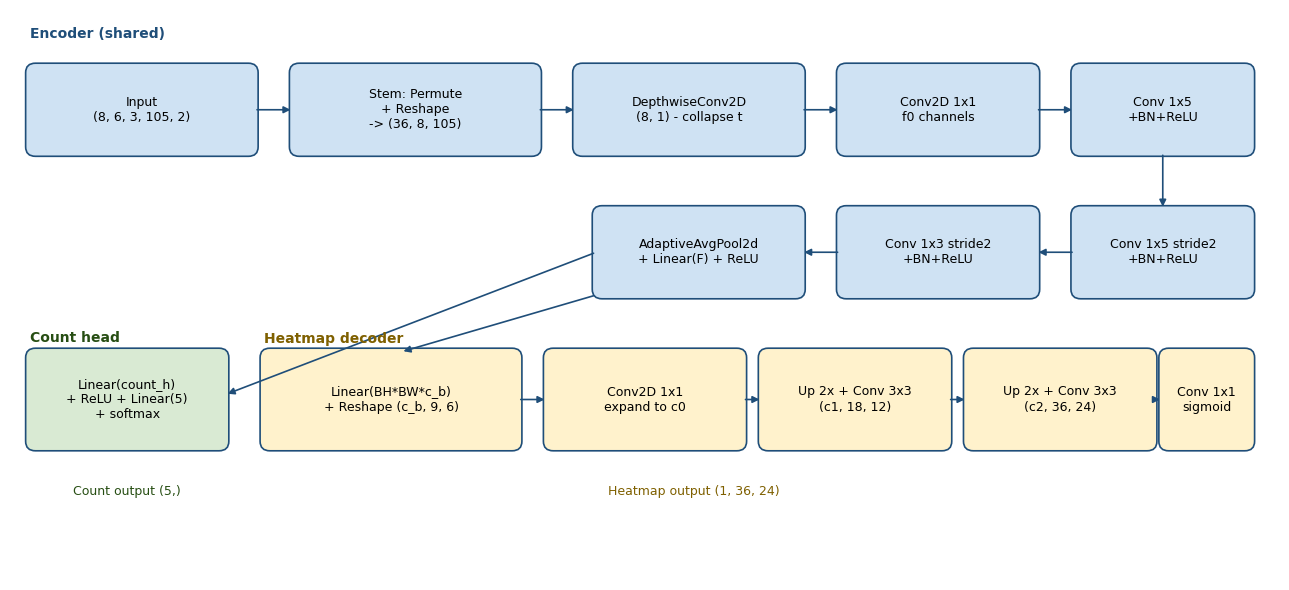

In [6]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 13)
ax.set_ylim(0, 6)
ax.axis("off")

def block(x, y, w, h, label, color="#cfe2f3"):
    ax.add_patch(FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.04,rounding_size=0.10",
        linewidth=1.2, edgecolor="#1f4e79", facecolor=color,
    ))
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=9)

def arrow(x0, y0, x1, y1):
    ax.add_patch(FancyArrowPatch(
        (x0, y0), (x1, y1),
        arrowstyle="-|>", mutation_scale=10, linewidth=1.2, color="#1f4e79",
    ))

# Encoder column
block(0.2, 4.5, 2.3, 0.9, "Input\n(8, 6, 3, 105, 2)")
block(2.9, 4.5, 2.5, 0.9, "Stem: Permute\n+ Reshape\n-> (36, 8, 105)")
block(5.8, 4.5, 2.3, 0.9, "DepthwiseConv2D\n(8, 1) - collapse t")
block(8.5, 4.5, 2.0, 0.9, "Conv2D 1x1\nf0 channels")
block(10.9, 4.5, 1.8, 0.9, "Conv 1x5\n+BN+ReLU")
arrow(2.5, 4.95, 2.9, 4.95); arrow(5.4, 4.95, 5.8, 4.95)
arrow(8.1, 4.95, 8.5, 4.95); arrow(10.5, 4.95, 10.9, 4.95)

# Encoder continued
block(10.9, 3.0, 1.8, 0.9, "Conv 1x5 stride2\n+BN+ReLU")
block(8.5, 3.0, 2.0, 0.9, "Conv 1x3 stride2\n+BN+ReLU")
block(6.0, 3.0, 2.1, 0.9, "AdaptiveAvgPool2d\n+ Linear(F) + ReLU")
arrow(11.8, 4.5, 11.8, 3.9)
arrow(10.9, 3.45, 10.5, 3.45); arrow(8.5, 3.45, 8.1, 3.45)

# Two heads
block(2.6, 1.4, 2.6, 1.0, "Linear(BH*BW*c_b)\n+ Reshape (c_b, 9, 6)", color="#fff2cc")
block(5.5, 1.4, 2.0, 1.0, "Conv2D 1x1\nexpand to c0", color="#fff2cc")
block(7.7, 1.4, 1.9, 1.0, "Up 2x + Conv 3x3\n(c1, 18, 12)", color="#fff2cc")
block(9.8, 1.4, 1.9, 1.0, "Up 2x + Conv 3x3\n(c2, 36, 24)", color="#fff2cc")
block(11.8, 1.4, 0.9, 1.0, "Conv 1x1\nsigmoid", color="#fff2cc")
ax.text(7.0, 0.9, "Heatmap output (1, 36, 24)", ha="center", fontsize=9, color="#7f6000")
arrow(6.0, 3.0, 4.0, 2.4)
arrow(5.2, 1.9, 5.5, 1.9); arrow(7.5, 1.9, 7.7, 1.9)
arrow(9.6, 1.9, 9.8, 1.9); arrow(11.7, 1.9, 11.8, 1.9)

# Count head
block(0.2, 1.4, 2.0, 1.0, "Linear(count_h)\n+ ReLU + Linear(5)\n+ softmax", color="#d9ead3")
ax.text(1.2, 0.9, "Count output (5,)", ha="center", fontsize=9, color="#274e13")
arrow(6.0, 3.45, 2.2, 1.95)

ax.text(0.2, 5.7, "Encoder (shared)", fontsize=10, fontweight="bold", color="#1f4e79")
ax.text(2.6, 2.5, "Heatmap decoder", fontsize=10, fontweight="bold", color="#7f6000")
ax.text(0.2, 2.5, "Count head", fontsize=10, fontweight="bold", color="#274e13")

plt.tight_layout()
plt.savefig(FIG_DIR / "model_architecture.png", bbox_inches="tight")
plt.show()


## 5. TFLite conversion (untrained, for size verification)

Convert each variant to INT8 TFLite using random calibration data, write the .tflite file to disk, and load it back to inspect ops, tensors, and arena size.

This produces **untrained** TFLite models -- the goal here is to verify the binary fits the constraints, not to get accurate predictions. Trained models will be produced in Phase 5 and re-converted with the same recipe.

**Note:** PT2E quantization is memory-heavy (~3-5 GB peak per variant). On low-memory environments (e.g. 4 GB containers), run variants one at a time. On Colab, all three should run sequentially without issue.


In [7]:
# Warm BN stats for each variant before conversion
print("Warming up BN stats for each variant...")
torch.manual_seed(42)
for name, m in variants.items():
    m.train()
    with torch.no_grad():
        for _ in range(3):
            _ = m(torch.randn(4, T_CONTEXT, N_RADARS, N_ANT, N_BINS, N_IQ))
    m.eval()
    print(f"  {name}: done")
gc.collect()


Warming up BN stats for each variant...
  small: done
  medium: done
  large: done


32

In [8]:
def random_rep_dataset():
    """Representative data generator for INT8 calibration.

    For an untrained model we use random Gaussian noise. For trained
    models in notebook 05, use real preprocessed CIR snippets from the
    training split.
    """
    for _ in range(10):
        yield (torch.randn(1, T_CONTEXT, N_RADARS, N_ANT, N_BINS, N_IQ),)


tflite_results = {}
sample = (torch.randn(1, T_CONTEXT, N_RADARS, N_ANT, N_BINS, N_IQ),)

for name, m in variants.items():
    print(f"Converting {name}...")
    f32_path  = TFLITE_DIR / f"model_{name}_f32.tflite"
    int8_path = TFLITE_DIR / f"model_{name}_int8.tflite"

    f32_bytes  = convert_float32(m, sample, str(f32_path))
    gc.collect()
    int8_bytes = convert_int8(m, sample, random_rep_dataset, str(int8_path),
                              n_calibration=10)
    gc.collect()

    tflite_results[name] = {
        "params":   m.num_params,
        "f32_kb":   f32_bytes / 1024,
        "int8_kb":  int8_bytes / 1024,
        "f32_path": str(f32_path),
        "int8_path": str(int8_path),
    }
    print(f"  -> float32 TFLite: {f32_bytes/1024:>8.1f} KB")
    print(f"  -> INT8 TFLite   : {int8_bytes/1024:>8.1f} KB")


Converting small...


Failed to load /home/aman/miniconda3/envs/uni/lib/python3.12/site-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /home/aman/miniconda3/envs/uni/lib/python3.12/site-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /home/aman/miniconda3/envs/uni/lib/python3.12/site-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /home/aman/miniconda3/envs/uni/lib/python3.12/site-packages/torchao/_C_cutlass_90a.abi3.so


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:01) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

...

(00:06) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:00)

(00:06) [ DONE] LiteRT-Torch Convert (+00:06)

(00:00) [START] Write Model to 
/home/aman/Projects/TinyML-UWB-MultiPerson-Localization/other_files/tflite_models/model_large_int8.tflite

(00:00) [ DONE] Write Model to 
/home/aman/Projects/TinyML-UWB-MultiPerson-Localization/other_files/tflite_models/model_large_int8.tflite (+00:00)

  -> float32 TFLite:   2440.8 KB
  -> INT8 TFLite   :    673.2 KB


## 6. Inspect the INT8 TFLite models

Load each TFLite file and report:
- Number and types of ops
- Largest activation tensor (drives the SRAM arena estimate)
- Approximate tensor arena (~ 2x largest activation, a conservative upper bound)


In [9]:
# Print summary table
print(f"{'variant':>8s}  {'INT8':>9s}  {'<800?':>5s}  {'largest tensor':>22s}  {'arena est':>10s}  {'<400?':>5s}")
print("-" * 80)

analysis = {}
for name in variants:
    res = tflite_results[name]
    info = inspect_tflite(res["int8_path"])
    largest_shape, largest_bytes = info["largest_tensor"]
    arena_est_kb = info["arena_estimate_kb"]
    analysis[name] = info

    flash_ok = "[OK]" if res["int8_kb"] < ESP32_FLASH_KB else "[!!]"
    sram_ok  = "[OK]" if arena_est_kb < ESP32_SRAM_KB    else "[!!]"
    print(f"{name:>8s}  {res['int8_kb']:>6.1f}KB  {flash_ok:>5s}  "
          f"{str(largest_shape):>15s} ({largest_bytes/1024:>4.1f}KB)  "
          f"{arena_est_kb:>7.1f}KB  {sram_ok:>5s}")

print()
print("Op breakdown (medium variant):")
for op, n in sorted(analysis["medium"]["op_counts"].items()):
    print(f"  {op:<28s}  x{n}")


 variant       INT8  <800?          largest tensor   arena est  <400?
--------------------------------------------------------------------------------


I0000 00:00:1777646927.574333   56128 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777646929.539469   56128 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


   small   152.4KB   [OK]        (432, 96) (40.5KB)     81.0KB   [OK]
  medium   362.9KB   [OK]       (648, 160) (101.2KB)    202.5KB   [OK]
   large   673.2KB   [OK]       (864, 224) (189.0KB)    378.0KB   [OK]

Op breakdown (medium variant):
  CONV_2D                       x8
  DELEGATE                      x3
  DEPTHWISE_CONV_2D             x1
  DEQUANTIZE                    x2
  FULLY_CONNECTED               x4
  LOGISTIC                      x1
  MUL                           x1
  QUANTIZE                      x1
  RESHAPE                       x3
  RESIZE_NEAREST_NEIGHBOR       x2
  SOFTMAX                       x1
  SUM                           x1
  TRANSPOSE                     x3


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 7. Size and budget visualisation

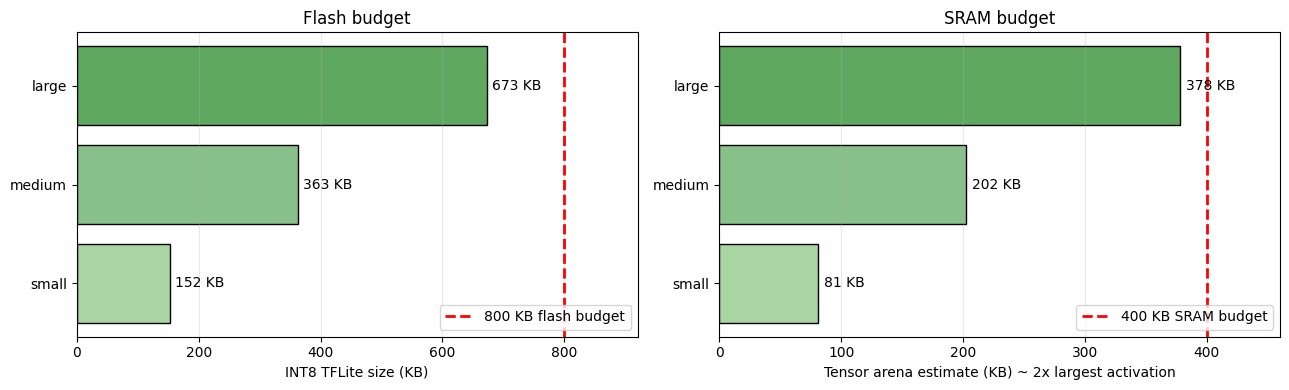

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

names = list(variants.keys())
int8_sizes = [tflite_results[n]["int8_kb"] for n in names]
arena_sizes = [analysis[n]["arena_estimate_kb"] for n in names]
colors_size = ["#a8d5a2", "#88c08a", "#5fa860"]

# Flash budget
axes[0].barh(names, int8_sizes, color=colors_size, edgecolor="black")
axes[0].axvline(ESP32_FLASH_KB, color="red", linestyle="--", linewidth=2,
                label=f"800 KB flash budget")
for i, (n, s) in enumerate(zip(names, int8_sizes)):
    axes[0].text(s + 8, i, f"{s:.0f} KB", va="center", fontsize=10)
axes[0].set_xlabel("INT8 TFLite size (KB)")
axes[0].set_title("Flash budget")
axes[0].legend(loc="lower right")
axes[0].set_xlim(0, ESP32_FLASH_KB * 1.15)
axes[0].grid(axis="x", alpha=0.3)

# SRAM budget
axes[1].barh(names, arena_sizes, color=colors_size, edgecolor="black")
axes[1].axvline(ESP32_SRAM_KB, color="red", linestyle="--", linewidth=2,
                label=f"400 KB SRAM budget")
for i, (n, s) in enumerate(zip(names, arena_sizes)):
    axes[1].text(s + 5, i, f"{s:.0f} KB", va="center", fontsize=10)
axes[1].set_xlabel("Tensor arena estimate (KB) ~ 2x largest activation")
axes[1].set_title("SRAM budget")
axes[1].legend(loc="lower right")
axes[1].set_xlim(0, ESP32_SRAM_KB * 1.15)
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "model_size_budgets.png", bbox_inches="tight")
plt.show()


## 8. Untrained heatmap output (sanity check)

Random initial weights produce a near-uniform sigmoid output around 0.5. After training, this will collapse toward zero everywhere except at the predicted person locations.


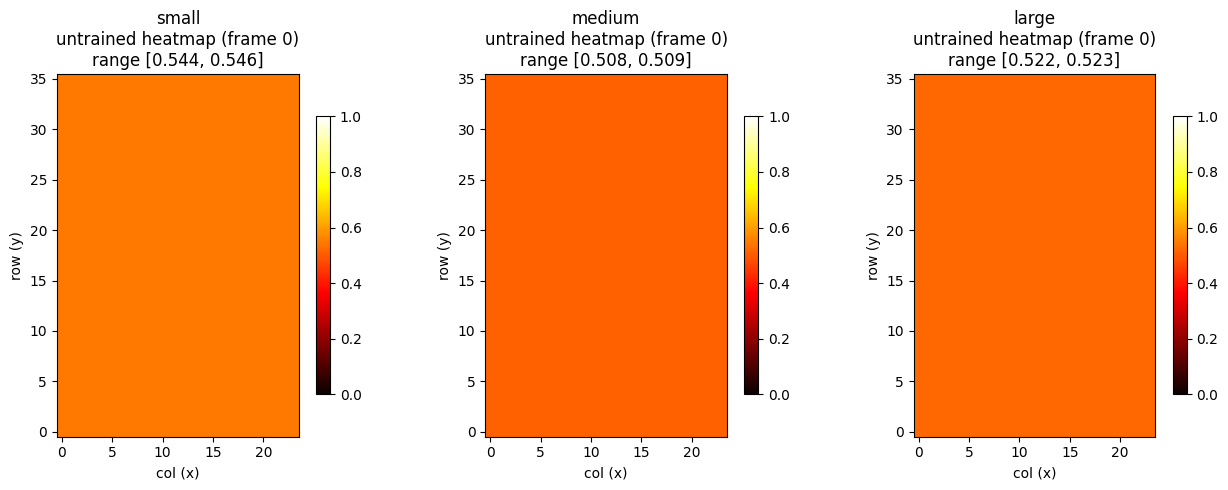

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, name in zip(axes, variants):
    hm, cnt = forward_results[name]
    # PyTorch NCHW: (B=2, C=1, H=36, W=24) -> show first sample
    img = hm[0, 0]
    im = ax.imshow(img, cmap="hot", vmin=0, vmax=1, origin="lower")
    ax.set_title(f"{name}\nuntrained heatmap (frame 0)\nrange [{img.min():.3f}, {img.max():.3f}]")
    ax.set_xlabel("col (x)")
    ax.set_ylabel("row (y)")
    plt.colorbar(im, ax=ax, fraction=0.04)

plt.tight_layout()
plt.savefig(FIG_DIR / "model_untrained_output.png", bbox_inches="tight")
plt.show()


## 9. PDF briefing

In [12]:
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle,
    Image as RLImage, PageBreak,
)
from PIL import Image as PILImage

OUT_PDF = OTHER_FILES / "eda_model.pdf"

ss = getSampleStyleSheet()
H1   = ParagraphStyle("H1",    parent=ss["Heading1"], fontSize=14, spaceAfter=4, spaceBefore=8,
                               textColor=colors.HexColor("#0b3d91"))
H2   = ParagraphStyle("H2",    parent=ss["Heading2"], fontSize=11, spaceAfter=2, spaceBefore=6,
                               textColor=colors.HexColor("#0b3d91"))
BODY = ParagraphStyle("body",  parent=ss["BodyText"], fontSize=8.5, leading=11)
SMALL= ParagraphStyle("small", parent=ss["BodyText"], fontSize=7.5, leading=9.5)

def tbl(data, col_widths=None, font_size=7.5, header=True):
    t = Table(data, colWidths=col_widths)
    style = [
        ("FONT", (0, 0), (-1, -1), "Helvetica", font_size),
        ("GRID", (0, 0), (-1, -1), 0.25, colors.grey),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("LEFTPADDING", (0, 0), (-1, -1), 3),
        ("RIGHTPADDING", (0, 0), (-1, -1), 3),
        ("TOPPADDING", (0, 0), (-1, -1), 1.5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 1.5),
    ]
    if header:
        style += [
            ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#e8eef7")),
            ("FONT", (0, 0), (-1, 0), "Helvetica-Bold", font_size),
        ]
    t.setStyle(TableStyle(style))
    return t

def fig(path, width=16*cm):
    p = Path(path)
    if not p.exists():
        return Paragraph(f"<i>(missing: {p.name})</i>", SMALL)
    with PILImage.open(p) as im:
        w, h = im.size
    return RLImage(str(p), width=width, height=width * (h / w))


doc = SimpleDocTemplate(
    str(OUT_PDF), pagesize=A4,
    leftMargin=1.5*cm, rightMargin=1.5*cm,
    topMargin=1.2*cm, bottomMargin=1.2*cm,
    title="Model Architecture Briefing - Multi-Person UWB Localization (PyTorch)",
)
story = []

story.append(Paragraph("Model Architecture Briefing - Multi-Person UWB Localization", H1))
story.append(Paragraph(
    f"Generated {datetime.now():%Y-%m-%d %H:%M} - PyTorch implementation - "
    f"3 size variants - Hybrid heatmap + count head - "
    f"INT8 quantized via litert-torch (PT2E); tested on untrained weights "
    f"for size verification",
    SMALL,
))
story.append(Spacer(1, 4))

# 1. Architecture diagram
story.append(Paragraph("1. Architecture (shared across variants)", H2))
story.append(Paragraph(
    "All three variants share the same encoder + decoder + count head structure; "
    "they differ only in the channel widths of each stage. The encoder maps the "
    "(8, 6, 3, 105, 2) stacked input to a flat feature vector via a depthwise temporal "
    "collapse followed by four range-direction convolutions. The heatmap decoder "
    "expands a (9, 6) bottleneck back to the (36, 24) room grid via two 2x upsampling "
    "stages. The count head is a small MLP on the same bottleneck features.",
    BODY,
))
story.append(fig(FIG_DIR / "model_architecture.png", width=17*cm))

# 2. Variant configurations
story.append(PageBreak())
story.append(Paragraph("2. Variant configurations", H2))
story.append(Paragraph(
    "The three variants are designed to span the size budget. Channel widths increase "
    "monotonically; the decoder bottleneck channel count <i>c_b</i> is small to keep the "
    "Linear projection from dominating the parameter budget.",
    BODY,
))
var_rows = [["Variant", "Encoder channels", "Feature width", "c_b", "Decoder ch (c0, c1, c2)", "Count hidden"]]
for name, v in MODEL_VARIANTS.items():
    var_rows.append([
        name,
        ", ".join(str(x) for x in v.enc_filters),
        str(v.feature_width),
        str(v.bottleneck_chan),
        ", ".join(str(x) for x in v.decoder_channels),
        str(v.count_hidden),
    ])
story.append(tbl(var_rows, col_widths=[2*cm, 4*cm, 2.5*cm, 1.5*cm, 4*cm, 2.5*cm]))

# 3. Sizes
story.append(Spacer(1, 6))
story.append(Paragraph("3. Parameter counts and TFLite binary sizes", H2))
story.append(Paragraph(
    "TFLite sizes measured from real conversions via the litert-torch package "
    "(formerly ai-edge-torch). INT8 quantization uses PT2E with random calibration "
    "data; trained models will use real preprocessed CIR snippets and produce the "
    "same binary size.",
    BODY,
))
size_rows = [["Variant", "Params", "Float32 (raw)", "Float32 TFLite", "INT8 TFLite", "Compression vs raw"]]
for name in variants:
    res = tflite_results[name]
    raw_kb = res["params"] * 4 / 1024
    int8_kb = res["int8_kb"]
    f32_kb = res["f32_kb"]
    compress = raw_kb / int8_kb if int8_kb > 0 else 0
    size_rows.append([
        name,
        f"{res['params']:,}",
        f"{raw_kb:.1f} KB",
        f"{f32_kb:.1f} KB",
        f"{int8_kb:.1f} KB",
        f"{compress:.2f}x",
    ])
story.append(tbl(size_rows, col_widths=[2*cm, 2.2*cm, 2.5*cm, 2.5*cm, 2.5*cm, 2.5*cm]))

# 4. Budget compliance
story.append(Spacer(1, 6))
story.append(Paragraph("4. ESP32-S3 budget compliance", H2))
budget_rows = [["Variant", "INT8 size", "Flash limit", "Flash OK?",
                "Largest tensor", "Arena est.", "SRAM limit", "SRAM OK?"]]
for name in variants:
    res = tflite_results[name]
    info = analysis[name]
    largest_shape, largest_bytes = info["largest_tensor"]
    arena_kb = info["arena_estimate_kb"]
    flash_ok = "Y" if res["int8_kb"] < ESP32_FLASH_KB else "N"
    sram_ok = "Y" if arena_kb < ESP32_SRAM_KB else "N"
    budget_rows.append([
        name,
        f"{res['int8_kb']:.1f} KB",
        f"{ESP32_FLASH_KB} KB",
        flash_ok,
        f"{largest_bytes/1024:.1f} KB",
        f"{arena_kb:.1f} KB",
        f"{ESP32_SRAM_KB} KB",
        sram_ok,
    ])
story.append(tbl(budget_rows, col_widths=[1.6*cm, 1.8*cm, 1.6*cm, 1.4*cm, 2*cm, 2*cm, 1.6*cm, 1.4*cm], font_size=7))

story.append(Spacer(1, 4))
story.append(fig(FIG_DIR / "model_size_budgets.png", width=17*cm))

# 5. Op set
story.append(PageBreak())
story.append(Paragraph("5. TFLite operation set", H2))
story.append(Paragraph(
    "The INT8 graph contains only operations on the TFLM supported list. No "
    "LSTM/GRU/RNN, no Conv2DTranspose, no SUM. Counts shown for the medium variant; "
    "the small and large variants use an identical op set.",
    BODY,
))
op_counts = analysis["medium"]["op_counts"]
op_rows = [["Op", "Count", "TFLM supported?"]]
for op, n in sorted(op_counts.items()):
    op_rows.append([op, str(n), "Yes"])
story.append(tbl(op_rows, col_widths=[6*cm, 2*cm, 4*cm]))

# 6. Untrained output
story.append(Spacer(1, 6))
story.append(Paragraph("6. Untrained output sanity check", H2))
story.append(Paragraph(
    "Untrained models produce a near-uniform sigmoid heatmap around 0.5 -- the network "
    "has not yet learned to distinguish presence from absence. After training, the "
    "heatmap collapses toward zero everywhere except at predicted person cells.",
    BODY,
))
story.append(fig(FIG_DIR / "model_untrained_output.png", width=17*cm))

# 7. Conversion recipe
story.append(Spacer(1, 6))
story.append(Paragraph("7. Conversion recipe (PyTorch -> TFLite via litert-torch)", H2))
story.append(Paragraph(
    "Conversion uses the litert-torch package which lowers PyTorch models through "
    "torch.export and StableHLO to TFLite. INT8 quantization uses PyTorch 2's PT2E "
    "framework. Encapsulated in <font face='Courier'>convert_to_litert.py</font>:",
    BODY,
))
recipe = [
    "1. Set the model to eval mode (no BN updates during conversion).",
    "2. Build a PT2EQuantizer with symmetric per-channel quantization config.",
    "3. Export the model graph via torch.export.export(model, sample_inputs).",
    "4. Insert observers via prepare_pt2e(graph, quantizer).",
    "5. Calibrate by running representative inputs through the prepared model.",
    "6. Convert to a quantized graph via convert_pt2e(prepared, fold_quantize=False).",
    "7. Lower to TFLite via litert_torch.convert(quantized, sample_inputs, quant_config).",
    "",
    "Note: x.mean(dim=...) compiles to a SUM op that is not on every TFLM build's default OpResolver. "
    "We use F.adaptive_avg_pool2d(x, 1) instead, which compiles cleanly to a MEAN op.",
]
for line in recipe:
    story.append(Paragraph(line, BODY))

doc.build(story)
print(f"Wrote {OUT_PDF}  ({OUT_PDF.stat().st_size/1024:.1f} KB)")


Wrote /home/aman/Projects/TinyML-UWB-MultiPerson-Localization/other_files/eda_model.pdf  (247.7 KB)


## Done

Artifacts produced:
- `other_files/tflite_models/model_{small,medium,large}_{f32,int8}.tflite` -- six TFLite files (untrained)
- `other_files/figs_eda/model_*.png` -- three figures
- `other_files/eda_model.pdf` -- briefing PDF

Send me the PDF and I'll update the architecture section of the report if any numbers changed (the main change is the conversion recipe and the use of `litert-torch` instead of `tf.lite.TFLiteConverter`).

**Next phase:** Phase 5 -- training pipeline in PyTorch. We'll rewrite `05_training.ipynb` with a `torch.utils.data.IterableDataset`, manual training loop with `tqdm` progress bars, and a custom distillation trainer.
